# Practical Statistics for Data Scientists (Python)
# Chapter 2. Data and Sampling Distributions
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck

**Reproduksi dan pembahasan:** Nanda Pratama ITM · NIM 101032330212 · TK 47 01.

Kode diadaptasi dari repositori resmi Peter Bruce, Andrew Bruce, dan Peter Gedeck (GPL-3.0); bukan klaim kode orisinal mahasiswa. Penjelasan Indonesia dan eksperimen tambahan disusun dengan bantuan AI. Sumber serta koreksi tercatat pada README dan docs/PERUBAHAN.md.

## Petunjuk penggunaan dan sumber

Baca teori berikut, kemudian jalankan sel kode berurutan dari atas ke bawah. Bagian **Reproduksi kode buku** mempertahankan semua sel Python nonkosong sumber resmi dengan koreksi yang dicatat. Bagian **Eksperimen tambahan** adalah pengembangan edukatif. Notebook gabungan ini telah dijalankan berurutan pada kernel baru, termasuk eksperimen tambahan.

Referensi utama: Bruce, Bruce, & Gedeck (2020), *Practical Statistics for Data Scientists*, edisi ke-2. [Kode resmi](https://github.com/gedeck/practical-statistics-for-data-scientists), commit `8a6d3bb6468e979c861d4b37215e1413702dfdfa`. Lihat [catatan perubahan](../docs/PERUBAHAN.md).

# Ringkasan dan pendalaman teori Bab 2

Bab ini menjelaskan bagaimana statistik berubah ketika sampel berubah. Distribusi data individual, distribusi sampling statistik, dan distribusi model teoretis adalah objek berbeda. Perbedaan ini mendasari standard error, confidence interval, dan penilaian ketidakpastian.


## Populasi, sampling, dan bias
Populasi adalah seluruh unit sasaran, sedangkan sampel bagian yang diamati. Parameter seperti mu tetap dalam pendekatan frequentist; statistik seperti mean sampel berubah antar sampel. Random sampling memberi mekanisme peluang pada pemilihan unit. Dengan pengembalian, satu unit dapat terpilih ulang; tanpa pengembalian tidak. Stratified sampling menjaga representasi subkelompok; cluster sampling mengambil kelompok dan membutuhkan perhatian terhadap dependensi dalam kelompok.

Bias adalah kesalahan sistematis. Sampel besar mengurangi variasi sampling tetapi tidak menyembuhkan selection bias, nonresponse, atau cakupan populasi yang buruk. Random selection terkait representativitas; random assignment pada eksperimen terkait pembandingan perlakuan. Selection bias juga muncul ketika hanya melaporkan pola paling menarik setelah mencoba banyak kandidat. Regression to the mean berarti nilai yang ekstrem akibat campuran sinyal dan noise cenderung kurang ekstrem pada pengukuran ulang, tanpa perlu efek perlakuan.


## Distribusi sampling, CLT, dan standard error
Distribusi sampling menggambarkan suatu statistik pada pengulangan sampling dengan ukuran serta mekanisme yang sama. Simulasi pendapatan membandingkan observasi individual dengan rata-rata sampel ukuran 5 dan 20. Distribusi rata-rata biasanya lebih terkonsentrasi.

Untuk pengamatan identik dan independen dengan varians terbatas, central limit theorem menyatakan bahwa rata-rata yang distandardisasi mendekati normal saat n besar. Ini tidak menyatakan data mentah menjadi normal. Standard error mean dapat diestimasi dengan $SE(\bar{x})\approx s/\sqrt n$. Memperbesar n empat kali kira-kira membagi SE menjadi dua. Data temporal atau berkelompok membutuhkan penyesuaian; rumus independensi dapat terlalu optimistis.


## Bootstrap
Bootstrap mengambil sampel ulang berukuran n dengan pengembalian dari data, lalu menghitung statistik pada setiap replikasi. Simpangan baku statistik bootstrap mengestimasi SE. Rata-rata bootstrap dikurangi statistik awal mengestimasi bias bootstrap. Pada contoh, statistiknya median pendapatan, bukan hanya mean. Menambah replikasi mengurangi noise Monte Carlo, bukan menciptakan informasi populasi baru.

Bootstrap adalah jenis resampling; permutation test mengacak label di bawah H0 dan menjawab pertanyaan berbeda. Bootstrap tidak memperbaiki sampel yang tidak representatif. Dependensi temporal dapat membutuhkan block bootstrap. Untuk sampel kecil atau statistik ekstrem, cakupan interval persentil dapat kurang baik.


## Confidence interval
Interval bootstrap persentil 90% memakai kuantil 0.05 dan 0.95; interval 95% memakai 0.025 dan 0.975. Interval 95% biasanya lebih lebar. Makna frequentist 95% adalah prosedur mencakup parameter sebenarnya pada sekitar 95% pengulangan sampling sesuai asumsi. Bukan berarti 95% observasi berada di interval, dan bukan probabilitas frequentist parameter tetap berada dalam satu interval yang sudah dihitung. Prediction interval untuk observasi baru biasanya lebih lebar karena memasukkan variasi individual.


## Normal, QQ-plot, dan ekor panjang
Distribusi normal simetris dengan parameter mean mu dan skala sigma. Standardisasi $z=(x-\mu)/\sigma$ menghasilkan normal standar jika x normal. QQ-plot membandingkan kuantil data dengan acuan. Kedekatan pada garis lurus mendukung kesesuaian bentuk; slope tidak harus satu bila data tidak memiliki skala standar. Penyimpangan ekor menunjukkan frekuensi ekstrem berbeda dari acuan.

Contoh NFLX resmi dipertahankan sebagai reproduksi transformasi. `sp500_data` berisi perubahan harga; menyaring nilai positif kemudian mengambil selisih log tidak boleh diklaim sebagai return log dari seri harga lengkap. Diagram itu menggambarkan hasil transformasi tersebut. Tambahan notebook menampilkan QQ-plot perubahan asli dengan garis fit. Distribusi berekor panjang membutuhkan perhatian ketika mengestimasi mean dan memakai asumsi normal.


## Student t, chi-square, dan F
Distribusi t simetris dengan ekor lebih berat daripada normal. Pada data normal independen dengan sigma tidak diketahui, $(\bar{x}-\mu)/(s/\sqrt n)$ mengikuti t dengan n-1 derajat bebas. t mendekati normal ketika derajat bebas besar.

Chi-square dengan k derajat bebas adalah jumlah kuadrat k normal standar independen. Distribusi ini nonnegatif dan digunakan dalam inferensi varians serta tabel kontingensi. F adalah rasio dua chi-square independen yang dibagi derajat bebas masing-masing: $F=(U/d_1)/(V/d_2)$. F mendasari ANOVA dan pembandingan model tertentu. Pemilihan distribusi harus mengikuti statistik uji dan asumsi, bukan sekadar kemiripan histogram.


## Binomial dan keluarga kejadian
Binomial menghitung sukses dari n percobaan independen dengan peluang p tetap: $P(X=k)={n\choose k}p^k(1-p)^{n-k}$, mean np, varians np(1-p). PMF memberi peluang tepat k; CDF peluang paling banyak k.

Poisson memodelkan hitungan pada interval dengan laju konstan: $P(X=k)=e^{-\lambda}\lambda^k/k!$, mean dan varians lambda. Varians jauh lebih besar dapat menunjukkan overdispersion. Pada proses Poisson, waktu antar kejadian mengikuti eksponensial dengan mean $1/\lambda$; `scale=5` berarti mean lima satuan waktu, bukan laju lima. Hazard eksponensial konstan dan bersifat memoryless.

Weibull memiliki survival $S(t)=\exp[-(t/\eta)^k]$. Shape k<1 memberi hazard menurun, k=1 eksponensial, k>1 hazard meningkat. Laju kegagalan membutuhkan exposure/waktu observasi, bukan hitungan mentah saja; censoring perlu dipertimbangkan dalam data survival.


## Interpretasi reproduksi dan kesimpulan
Bandingkan lebar distribusi mean ukuran 5 dan 20, SE bootstrap median, serta interval 90% dan 95%. Seed membuat hasil simulasi dapat diulang tetapi tidak mengubah validitas asumsi. Dalam ML/DL, konsep ini membantu memisahkan variasi akibat split data dari perbaikan model yang konsisten.


# Reproduksi kode buku
Sel berikut diadaptasi dari penulis asli. Komentar Inggris dipertahankan untuk memudahkan pencocokan sumber. Teori serta interpretasi Indonesia tersedia di atas dan pada bagian akhir.

## Persiapan kernel: jalankan sebelum kode bab

`ModuleNotFoundError` berarti modul belum tersedia di kernel yang dipilih. Sel berikut memeriksa dependensi dan memasang paket yang diperlukan **ke Python yang sedang dipakai notebook**, bukan ke Python lain. Pemasangan pertama memerlukan internet dan dapat memakan beberapa menit. Gunakan Python 3.12 (versi pengujian). Setelah itu, jalankan kode bab dari atas ke bawah. Jika masih gagal, perhatikan nama modul dan pesan pemasangan yang muncul; jangan melewati sel persiapan.

In [1]:
# Jalankan sel ini lebih dahulu: paket dipasang ke Python/kernel yang aktif.
import sys
import importlib.util
import importlib
import subprocess
from pathlib import Path

REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'requirements-lock.txt').is_file() and (p / 'data').is_dir()), None)
if REPO is None:
    raise FileNotFoundError('Buka folder Practical-Statistics-for-Data-Scientists di VS Code, lalu buka notebook dari folder notebooks.')

paket = {
    'numpy': 'numpy', 'pandas': 'pandas', 'scipy': 'scipy',
    'matplotlib': 'matplotlib', 'seaborn': 'seaborn', 'sklearn': 'scikit-learn',
    'statsmodels': 'statsmodels', 'wquantiles': 'wquantiles', 'pygam': 'pygam',
    'dmba': 'dmba', 'pydotplus': 'pydotplus', 'imblearn': 'imbalanced-learn',
    'xgboost': 'xgboost', 'prince': 'prince', 'adjustText': 'adjustText',
    'IPython': 'ipython', 'graphviz': 'graphviz'
}
kurang = [nama for modul, nama in paket.items() if importlib.util.find_spec(modul) is None]
print('Python/kernel aktif:', sys.executable)
print('Versi Python:', sys.version.split()[0])
if kurang:
    print('Paket belum tersedia:', ', '.join(kurang))
    print('Memasang dependensi ke kernel ini. Internet diperlukan pada pemasangan pertama.')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(REPO / 'requirements-lock.txt')])
    importlib.invalidate_caches()
    print('Pemasangan selesai. Jika library sudah diimpor sebelum pemasangan, pilih Restart Kernel lalu Run All.')
else:
    print('Semua dependensi tersedia. Lanjutkan sel berikutnya secara berurutan.')

Python/kernel aktif: D:\Kuliah\DL\.venv-statistics\Scripts\python.exe
Versi Python: 3.12.14
Semua dependensi tersedia. Lanjutkan sel berikutnya secara berurutan.


In [2]:
import random
import numpy as np
random.seed(42)
np.random.seed(42)
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})

Import required Python packages.

In [3]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.utils import resample

import seaborn as sns
import matplotlib.pylab as plt

In [4]:
DATA = next((p / 'data' for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'state.csv').exists()), None)
assert DATA is not None, 'Jalankan notebook dari folder repositori atau notebooks.'
print('Data:', DATA)

Data: D:\Kuliah\DL\UPLOAD_GITHUB\Practical-Statistics-for-Data-Scientists\data


Define paths to data sets. If you don't keep your data in the same directory as the code, adapt the path names.

In [5]:
LOANS_INCOME_CSV = DATA / 'loans_income.csv'
SP500_DATA_CSV = DATA / 'sp500_data.csv.gz'

Figure 2.1

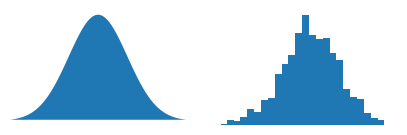

In [6]:
np.random.seed(seed=1)
x = np.linspace(-3, 3, 300)
xsample = stats.norm.rvs(size=1000)

fig, axes = plt.subplots(ncols=2, figsize=(5, 1.5))

ax = axes[0]
ax.fill(x, stats.norm.pdf(x))
ax.set_axis_off()
ax.set_xlim(-3, 3)

ax = axes[1]
ax.hist(xsample, bins=30)
ax.set_axis_off()
ax.set_xlim(-3, 3)
ax.set_position
# plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0)

plt.show()

# Sampling Distribution of a Statistic

In [7]:
loans_income = pd.read_csv(LOANS_INCOME_CSV).squeeze('columns')

sample_data = pd.DataFrame({
    'income': loans_income.sample(1000),
    'type': 'Data',
})

sample_mean_05 = pd.DataFrame({
    'income': [loans_income.sample(5).mean() for _ in range(1000)],
    'type': 'Mean of 5',
})

sample_mean_20 = pd.DataFrame({
    'income': [loans_income.sample(20).mean() for _ in range(1000)],
    'type': 'Mean of 20',
})

results = pd.concat([sample_data, sample_mean_05, sample_mean_20])
print(results.head())

         income  type
40292   63000.0  Data
38959   92000.0  Data
17361  134000.0  Data
33996   52000.0  Data
26491   43000.0  Data


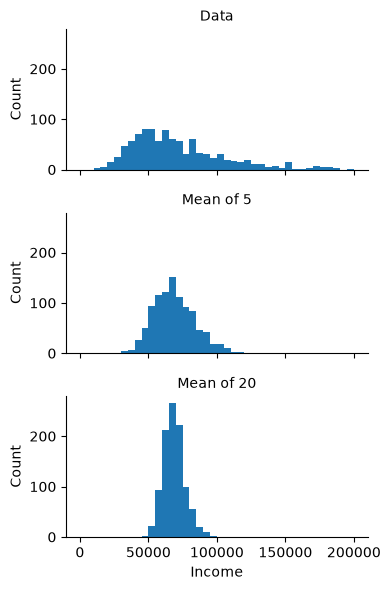

In [8]:
g = sns.FacetGrid(results, col='type', col_wrap=1, 
                  height=2, aspect=2)
g.map(plt.hist, 'income', range=[0, 200000], bins=40)
g.set_axis_labels('Income', 'Count')
g.set_titles('{col_name}')

plt.tight_layout()
plt.show()

# The Bootstrap

In [9]:
results = []
for nrepeat in range(1000):
    sample = resample(loans_income)
    results.append(sample.median())
results = pd.Series(results)
print('Bootstrap Statistics:')
print(f'original: {loans_income.median()}')
print(f'bias: {results.mean() - loans_income.median()}')
print(f'std. error: {results.std()}')

Bootstrap Statistics:
original: 62000.0
bias: -82.09799999999814
std. error: 228.73933106830927


# Confidence Intervals

68760.51844
55734.1


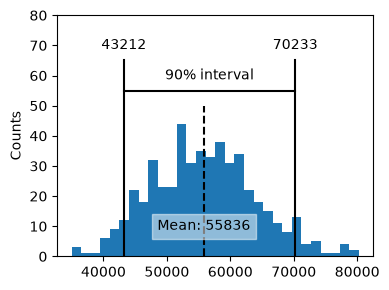

In [10]:
print(loans_income.mean())
np.random.seed(seed=3)  
# create a sample of 20 loan income data
sample20 = resample(loans_income, n_samples=20, replace=False)
print(sample20.mean())
results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [55, 55], color='black')
for x in confidence_interval:
    ax.plot([x, x], [0, 65], color='black')
    ax.text(x, 70, f'{x:.0f}', 
            horizontalalignment='center', verticalalignment='center')
ax.text(sum(confidence_interval) / 2, 60, '90% interval',
        horizontalalignment='center', verticalalignment='center')

meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color='black', linestyle='--')
ax.text(meanIncome, 10, f'Mean: {meanIncome:.0f}',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80)
ax.set_ylabel('Counts')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Counts')

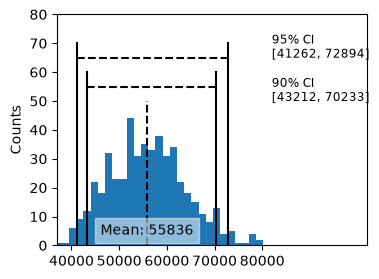

In [11]:
np.random.seed(seed=3)
# create a sample of 20 loan income data
sample20 = resample(loans_income, n_samples=20, replace=False)

results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3), color='C1')
ax.plot(confidence_interval, [55, 55], color='black', linestyle='--')
for x in confidence_interval:
    ax.plot([x, x], [0, 60], color='black')
ax.text(82000, 50, 
        f'90% CI\n[{confidence_interval[0]:.0f}, {confidence_interval[1]:.0f}]',
       fontsize='small')

confidence_interval = list(results.quantile([0.025, 0.975]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [65, 65], color='black', linestyle='--')
for x in confidence_interval:
    ax.plot([x, x], [0, 70], color='black')
ax.text(82000, 65, 
        f'95% CI\n[{confidence_interval[0]:.0f}, {confidence_interval[1]:.0f}]',
       fontsize='small')
# ax.text(sum(confidence_interval) / 2, 264, '95 % interval',
#         horizontalalignment='center', verticalalignment='center')

meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color='black', linestyle='--')
ax.text(meanIncome, 5, f'Mean: {meanIncome:.0f}',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80)
ax.set_xlim(37000, 102000)
ax.set_xticks([40000, 50000, 60000, 70000, 80000])
ax.set_ylabel('Counts')

# plt.tight_layout()
# plt.show()

# Normal Distribution
## Standard Normal and QQ-Plots
The package _scipy_ has the function (`scipy.stats.probplot`) to create QQ-plots. The argument `dist` specifies the distribution, which is set by default to the normal distribution.

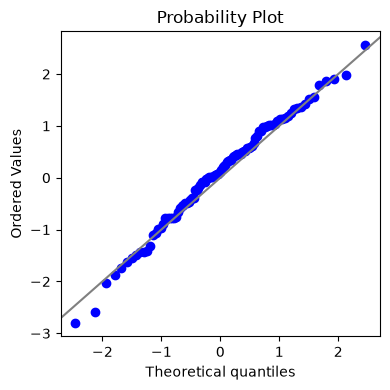

In [12]:
fig, ax = plt.subplots(figsize=(4, 4))

norm_sample = stats.norm.rvs(size=100)
# Use fit=False to disable the default fitting of a line to the sample data (least-squares regression).
stats.probplot(norm_sample, plot=ax, fit=False)
# Plot the diagonal representing the standardized normal distribution.
ax.axline((0, 0), (1, 1), color='gray')

plt.tight_layout()
plt.show()

# Long-Tailed Distributions

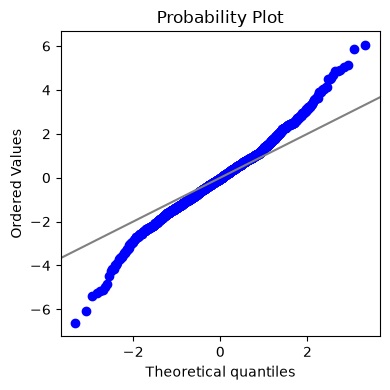

In [13]:
sp500_px = pd.read_csv(SP500_DATA_CSV)

nflx = sp500_px.NFLX
nflx = np.diff(np.log(nflx[nflx>0]))

fig, ax = plt.subplots(figsize=(4, 4))
# Use fit=False to disable the default fitting of a line to the sample data (least-squares regression).
stats.probplot(nflx, plot=ax, fit=False)
# Plot the diagonal representing the standardized normal distribution.
ax.axline((0, 0), (1, 1), color='gray')

plt.tight_layout()
plt.show()

# Binomial Distribution

In [14]:
print(stats.binom.pmf(2, n=5, p=0.1))

0.07289999999999992


In [15]:
print(stats.binom.cdf(2, n=5, p=0.1))

0.99144


# Poisson and Related Distribution
## Poisson Distributions

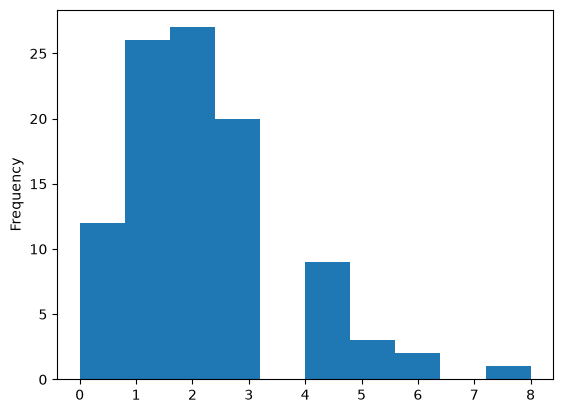

In [16]:
sample = stats.poisson.rvs(2, size=100)

pd.Series(sample).plot.hist()
plt.show()

## Exponential Distribution

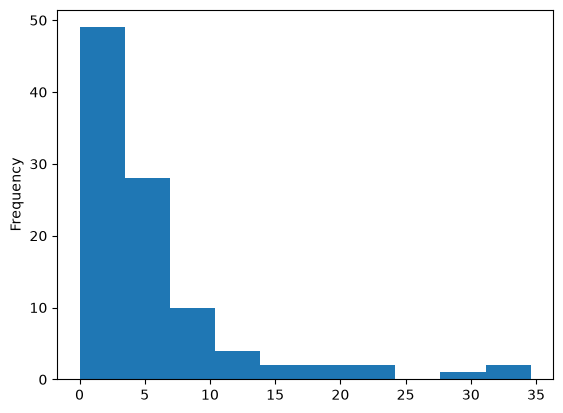

In [17]:
sample = stats.expon.rvs(scale=5, size=100)

pd.Series(sample).plot.hist()
plt.show()

##  Weibull Distribution

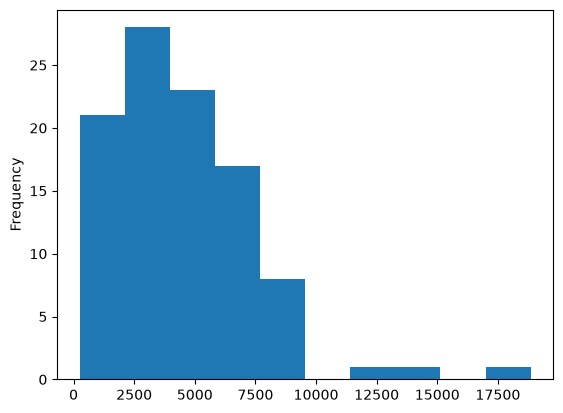

In [18]:
sample = stats.weibull_min.rvs(1.5, scale=5000, size=100)

pd.Series(sample).plot.hist()
plt.show()

# Eksperimen tambahan dan validasi
Sel berikut disusun sebagai pendalaman. Output muncul setelah sel kode dijalankan.

## Eksperimen tambahan: distribusi t, chi-square, F, dan QQ-plot data asli
Contoh ini melengkapi teori yang tidak mempunyai sel Python tersendiri dalam notebook sumber. Angka binomial diverifikasi terhadap rumus analitis.

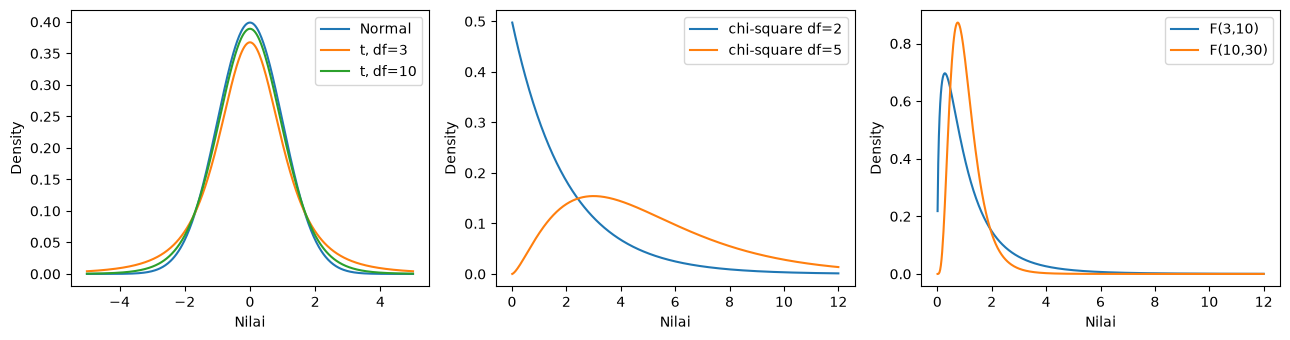

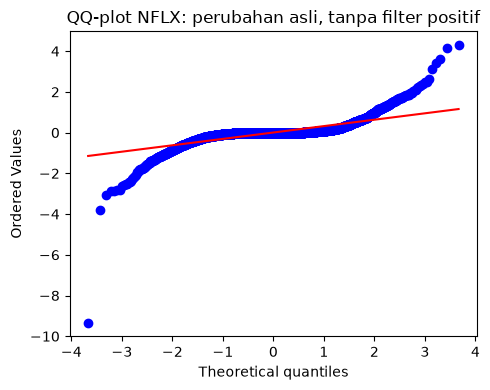

P(X=2): 0.07289999999999992 | P(X<=2): 0.99144


In [19]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
from math import comb
import matplotlib.pyplot as plt
DATA = next(p/'data' for p in [Path.cwd(), *Path.cwd().parents] if (p/'data'/'state.csv').exists())
assert np.isclose(stats.binom.pmf(2,5,.1), comb(5,2)*.1**2*.9**3)
assert np.isclose(stats.binom.cdf(2,5,.1), .99144)
fig, axes = plt.subplots(1,3,figsize=(13,3.5))
z = np.linspace(-5,5,500)
axes[0].plot(z,stats.norm.pdf(z),label='Normal')
for df in [3,10]: axes[0].plot(z,stats.t.pdf(z,df),label=f't, df={df}')
a = np.linspace(.01,12,500)
for df in [2,5]: axes[1].plot(a,stats.chi2.pdf(a,df),label=f'chi-square df={df}')
for d1,d2 in [(3,10),(10,30)]: axes[2].plot(a,stats.f.pdf(a,d1,d2),label=f'F({d1},{d2})')
for ax in axes: ax.legend(); ax.set_ylabel('Density'); ax.set_xlabel('Nilai')
plt.tight_layout(); plt.show()
px = pd.read_csv(DATA/'sp500_data.csv.gz', index_col=0)
fig, ax = plt.subplots(figsize=(5,4))
stats.probplot(px.NFLX.dropna(), dist='norm', plot=ax)
ax.set_title('QQ-plot NFLX: perubahan asli, tanpa filter positif')
plt.tight_layout(); plt.show()
print('P(X=2):',stats.binom.pmf(2,5,.1),'| P(X<=2):',stats.binom.cdf(2,5,.1))

**Interpretasi:** t dengan df kecil memiliki ekor lebih berat. Chi-square dan F tidak simetris seperti normal. Penyimpangan QQ-plot dibaca terhadap garis fit, tanpa mengasumsikan skala data sudah normal standar.

## Ringkasan hasil yang diperoleh

Jalankan semua sel sebelumnya, kemudian sel berikut untuk menampilkan ringkasan dari hasil perhitungan saat ini.

In [20]:
# Probabilitas baru dihitung dan ditampilkan saat sel dijalankan.
print('P(X=2):', stats.binom.pmf(2, n=5, p=0.1))
print('P(X<=2):', stats.binom.cdf(2, n=5, p=0.1))

P(X=2): 0.07289999999999992
P(X<=2): 0.99144
